# Derivadas y Diferenciacion

In [1]:
import sympy as sp

In [3]:
x = sp.symbols('x')
f = x**2 + 3*x + 2
print(f)

x**2 + 3*x + 2


### para imprimirlas mejor, uso el metodo prettyprint de sympy

In [4]:
sp.pretty_print(f)

 2          
x  + 3⋅x + 2


## Defino la derivada

In [5]:
h = sp.symbols('h')
f_limit = sp.limit((f.subs(x, x+h)-f)/h,h,0)


In [7]:
sp.pretty_print(f_limit)

2⋅x + 3


## Veo el diferencial

In [9]:
f_diff = sp.diff(f, x)
sp.pretty_print(f_diff)

2⋅x + 3


In [11]:
import numpy as np
import matplotlib.pyplot as plt


### convierto las funciones simbolicas a numericas

In [12]:
f_lambdify = sp.lambdify(x, f, 'numpy')
f_limit_lambdify = sp.lambdify(x, f_limit, 'numpy')
f_diff_lambdify = sp.lambdify(x, f_diff, 'numpy')

# creo valores de x
x_vals = np.linspace(-10, 10, 400)


In [13]:
y_vals = f_lambdify(x_vals)
y_limit_vals = f_limit_lambdify(x_vals)
y_diff_vals = f_diff_lambdify(x_vals)

## grafico funcion y derivadas

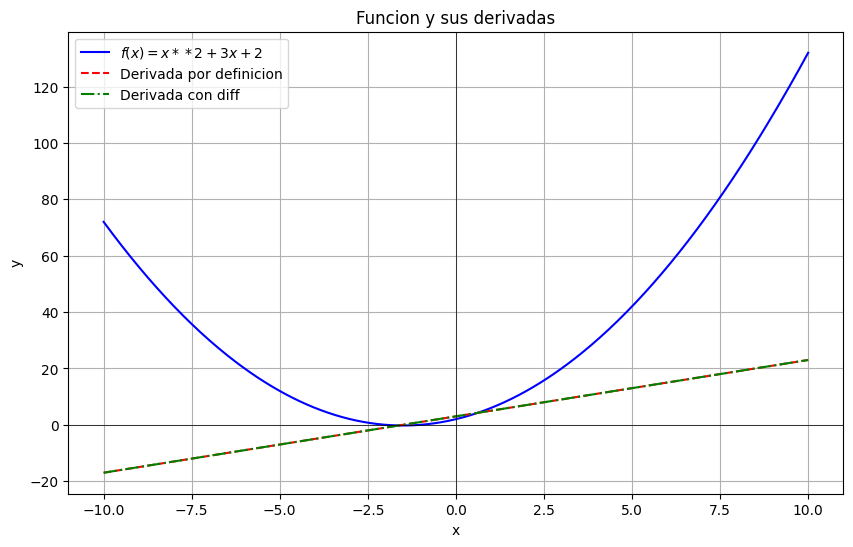

In [16]:
plt.figure(figsize=(10, 6))
plt.plot(x_vals, y_vals, label=r'$f(x)= x**2 + 3x + 2$', color= 'blue')
plt.plot(x_vals, y_limit_vals, label=r'Derivada por definicion', color= 'red', linestyle='--')
plt.plot(x_vals, y_diff_vals, label=r'Derivada con diff', color= 'green', linestyle='-.')
plt.title('Funcion y sus derivadas')
plt.xlabel('x')
plt.ylabel('y')
plt.axhline(0, color='black', lw=0.5)
plt.axvline(0, color='black', lw=0.5)
plt.legend()
plt.grid(True)
plt.show()

## Vemos las derivadas parciales de una funcion de dos variables

In [20]:
# Defino x e y
x,y = sp.symbols('x y')
f_xy = x**2 * y + y**3
sp.pretty_print(f_xy)

 2      3
x ⋅y + y 


In [22]:
# Hago derivada parcial con respecto a x
f_partial_x_limit = sp.limit((f_xy.subs(x, x+h)-f_xy)/h,  h,0)
sp.pretty_print(f_partial_x_limit)

2⋅x⋅y


In [23]:
# Hago derivada parcial con respecto a x usando diff
f_partial_x_diff = sp.diff(f_xy, x)
sp.pretty_print(f_partial_x_diff)


2⋅x⋅y


In [24]:
f_partial_y_limit = sp.limit((f_xy.subs(y, y+h)-f_xy)/h,  h,0)
sp.pretty_print(f_partial_y_limit)


 2      2
x  + 3⋅y 


In [25]:
f_partial_y_diff = sp.diff(f_xy, y)
sp.pretty_print(f_partial_y_diff)

 2      2
x  + 3⋅y 


# Aplicacion de Derivadas

In [27]:
# defino variable simbolica

x = sp.symbols('x')
f = x**3 - 6*x**2 + 9*x + 15
sp.pretty_print(f)

 3      2           
x  - 6⋅x  + 9⋅x + 15


In [28]:
# convierto a una funcion numerica con lambdified
f_lambdified = sp.lambdify(x, f, 'numpy')
x_vals = np.linspace(-1, 5, 400)
y_vals = f_lambdified(x_vals)

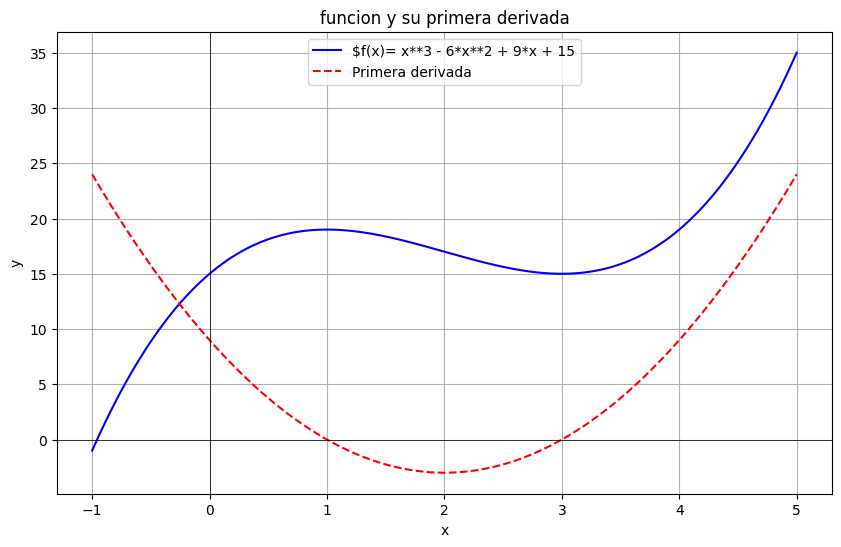

In [34]:
# grafico la funcion
plt.figure(figsize=(10, 6))
plt.plot(x_vals, y_vals, label=r'$f(x)= x**3 - 6*x**2 + 9*x + 15', color= 'blue')
plt.plot(x_vals, y_diff_vals, label=r'Primera derivada', color= 'red', linestyle='--')
plt.title('funcion y su primera derivada')
plt.xlabel('x')
plt.ylabel('y')
plt.axhline(0, color='black', lw=0.5)
plt.axvline(0, color='black', lw=0.5)
plt.legend()
plt.grid(True)
plt.show()

## derivamos la funcion original

In [31]:
f_diff = sp.diff(f, x)
f_diff_lambdified = sp.lambdify(x, f_diff, 'numpy')
sp.pretty_print(f_diff)


   2           
3⋅x  - 12⋅x + 9


In [32]:
# evaluo la derivada para graficar con la funcion original
y_diff_vals = f_diff_lambdified(x_vals)

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(x_vals, y_vals, label=r'$f(x)= x**3 - 6*x**2 + 9*x + 15', color= 'blue')
plt.title('funcion original')
plt.xlabel('x')
plt.ylabel('y')
plt.axhline(0, color='black', lw=0.5)
plt.axvline(0, color='black', lw=0.5)
plt.legend()
plt.grid(True)
plt.show()

## Ahora buscamos puntos criticos

In [35]:
# resolvemos la formula de la derivada igual a cero para encontrar puntos criticos
critical_points = sp.solve(f_diff, x)
# los muestro con un print
print("Puntos críticos:", critical_points)

Puntos críticos: [1, 3]


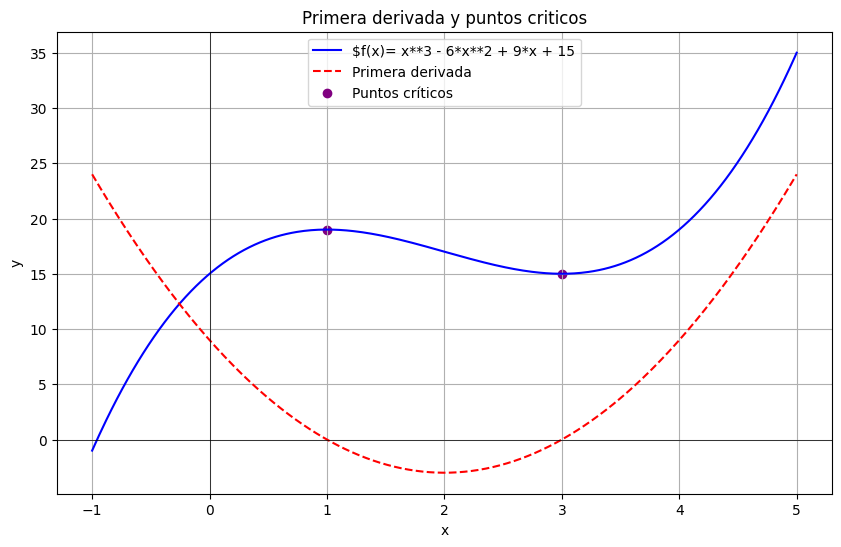

In [36]:
# grafico la primer derivada y la segunda derivada para analizar la concavidad
plt.figure(figsize=(10, 6))
plt.plot(x_vals, y_vals, label=r'$f(x)= x**3 - 6*x**2 + 9*x + 15', color= 'blue')
plt.plot(x_vals, y_diff_vals, label=r'Primera derivada', color= 'red', linestyle='--')

plt.title('Primera derivada y puntos criticos')
plt.xlabel('x')
plt.ylabel('y')
plt.axhline(0, color='black', lw=0.5)
plt.axvline(0, color='black', lw=0.5)
plt.scatter(critical_points, [f_lambdified(cp) for cp in critical_points], color='purple', label='Puntos críticos')
plt.legend()
plt.grid(True)
plt.show()



In [37]:
# derivo nuevamente para obtener la segunda derivada
f_diff2 = sp.diff(f_diff, x)
f_diff2_lambdified = sp.lambdify(x, f_diff2, 'numpy')
sp.pretty_print(f_diff2)

6⋅x - 12


In [38]:
# evaluo la segunda derivada para graficar con la funcion original
y_diff2_vals = f_diff2_lambdified(x_vals)

# puntos de infleccion igualando la segunda derivada a cero
inflection_points = sp.solve(f_diff2, x)

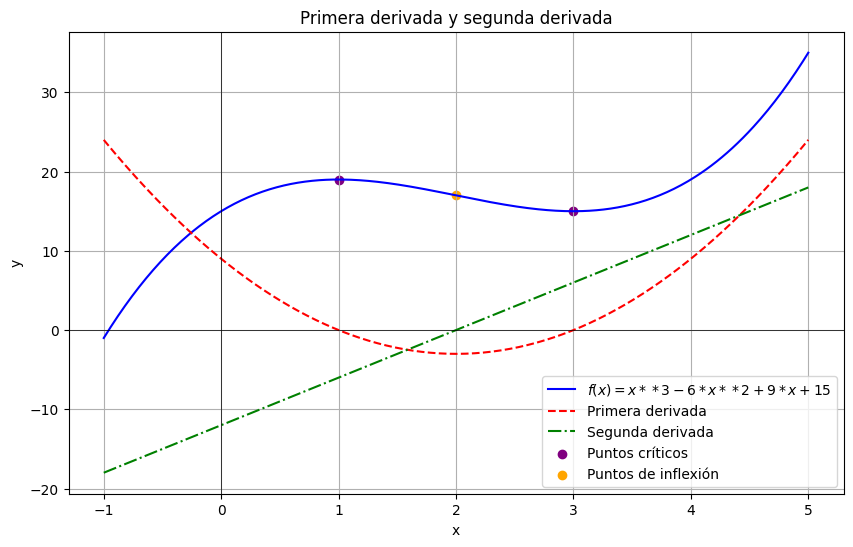

In [42]:
# grafico la primer derivada y la segunda derivada para analizar la concavidad
plt.figure(figsize=(10, 6))
plt.plot(x_vals, y_vals, label=r'$f(x)= x**3 - 6*x**2 + 9*x + 15$', color= 'blue')
plt.plot(x_vals, y_diff_vals, label=r'Primera derivada', color= 'red', linestyle='--')
plt.plot(x_vals, y_diff2_vals, label=r'Segunda derivada', color= 'green', linestyle='-.')
plt.title('Primera derivada y segunda derivada')
plt.xlabel('x')
plt.ylabel('y')
plt.axhline(0, color='black', lw=0.5)
plt.axvline(0, color='black', lw=0.5)
plt.scatter(critical_points, [f_lambdified(cp) for cp in critical_points], color='purple', label='Puntos críticos')
plt.scatter(inflection_points, [f_lambdified(ip) for ip in inflection_points], color='orange', label='Puntos de inflexión')
plt.legend()
plt.grid(True)
plt.show()

In [41]:
# para deterinar concavidad en el intervalo
concavidad = [(val, f_diff2_lambdified(val)) for val in x_vals]
concavidad_up = [c[0] for c in concavidad if c[1] > 0] # lista por comprension para obtener los valores de x donde la concavidad es positiva
concavidad_down = [c[0] for c in concavidad if c[1] < 0] # una lista por compresion significa que se va a iterar sobre cada elemento de la lista concavidad y se va a evaluar la condicion c[1] < 0, si es verdadera se agrega el valor c[0] a la lista concavidad_down
print("Intervalos de concavidad hacia arriba:", concavidad_up)
print("Intervalos de concavidad hacia abajo:", concavidad_down)

Intervalos de concavidad hacia arriba: [np.float64(2.007518796992481), np.float64(2.0225563909774436), np.float64(2.037593984962406), np.float64(2.052631578947368), np.float64(2.0676691729323307), np.float64(2.082706766917293), np.float64(2.0977443609022552), np.float64(2.1127819548872178), np.float64(2.1278195488721803), np.float64(2.142857142857143), np.float64(2.1578947368421053), np.float64(2.1729323308270674), np.float64(2.18796992481203), np.float64(2.2030075187969924), np.float64(2.2180451127819545), np.float64(2.233082706766917), np.float64(2.2481203007518795), np.float64(2.263157894736842), np.float64(2.2781954887218046), np.float64(2.2932330827067666), np.float64(2.308270676691729), np.float64(2.3233082706766917), np.float64(2.3383458646616537), np.float64(2.3533834586466162), np.float64(2.3684210526315788), np.float64(2.3834586466165413), np.float64(2.398496240601504), np.float64(2.413533834586466), np.float64(2.4285714285714284), np.float64(2.443609022556391), np.float64(2.